# Imports (Directly copy and pasted)

In [1]:
import matplotlib.pyplot as plt
import rustworkx as rx
from rustworkx.visualization import mpl_draw as draw_graph
import numpy as np
from scipy.optimize import minimize
from collections import defaultdict
from typing import Sequence


from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit.library import QAOAAnsatz
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager

from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_ibm_runtime import Session, EstimatorV2 as Estimator
from qiskit_ibm_runtime import SamplerV2 as Sampler

# Graph

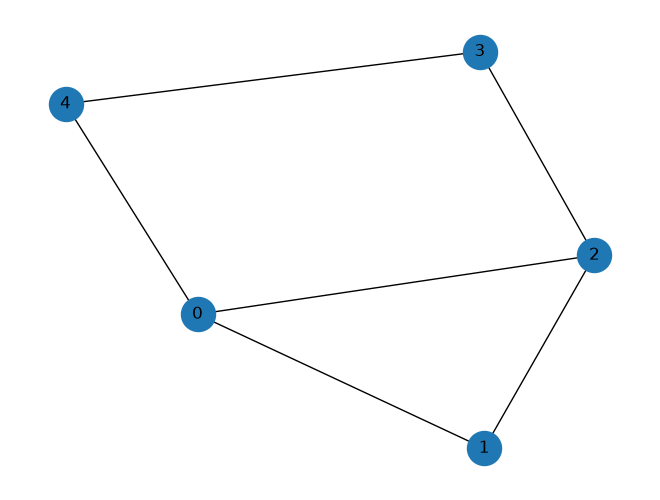

In [2]:
graph_nodes = 5

graph = rx.PyGraph()
graph.add_nodes_from(np.arange(0, graph_nodes, 1))
edge_list = [
    (0, 1, 1.0),
    (0, 2, 1.0),
    (0, 4, 1.0),
    (1, 2, 1.0),
    (2, 3, 1.0),
    (3, 4, 1.0),
]
graph.add_edges_from(edge_list)
draw_graph(graph, node_size=600, with_labels=True)

# Building the Hamiltonian

In [3]:
def build_max_cut_paulis(graph: rx.PyGraph) -> list[tuple[str, list[int], float]]:
    # Basically we encode every edge in I and Z gates. 
    # I'm not 100% sure why this works still
    pauli_list = []
    for edge in list(graph.edge_list()):
        weight = graph.get_edge_data(edge[0], edge[1])
        pauli_list.append(("ZZ", [edge[0], edge[1]], weight))
    return pauli_list

max_cut_paulis = build_max_cut_paulis(graph)
cost_hamiltonian = SparsePauliOp.from_sparse_list(max_cut_paulis, graph_nodes)
print("Cost Function Hamiltonian:", cost_hamiltonian)

Cost Function Hamiltonian: SparsePauliOp(['IIIZZ', 'IIZIZ', 'ZIIIZ', 'IIZZI', 'IZZII', 'ZZIII'],
              coeffs=[1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j, 1.+0.j])


# Making the Circuit (Thanks to qiskit for automating this)

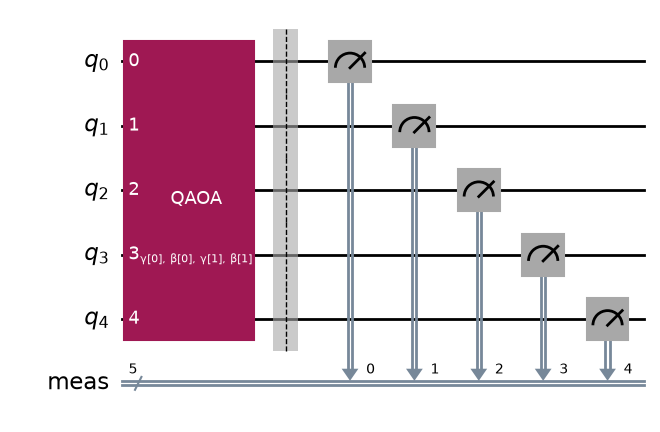

In [4]:
circuit = QAOAAnsatz(cost_operator=cost_hamiltonian, reps=2)
circuit.measure_all()
circuit.draw("mpl")

In [5]:
circuit.parameters

ParameterView([ParameterVectorElement(β[0]), ParameterVectorElement(β[1]), ParameterVectorElement(γ[0]), ParameterVectorElement(γ[1])])

# Now we let qiskit do the heavy lifting in making our circuit

In [6]:
from qiskit_ibm_runtime import QiskitRuntimeService
QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token="VCOTZ6Gp-lC87iRtXuO7UEYHw4ZOz2tKlxV7jMZpokmv", 
    overwrite=True, 
    instance="crn:v1:bluemix:public:quantum-computing:us-east:a/407ca19e17a241c49d094e4d01c47f57:61b62a1b-fdd6-4425-92d0-502f8dd00f40::", 
    set_as_default=True
)


<IBMBackend('ibm_kingston')>


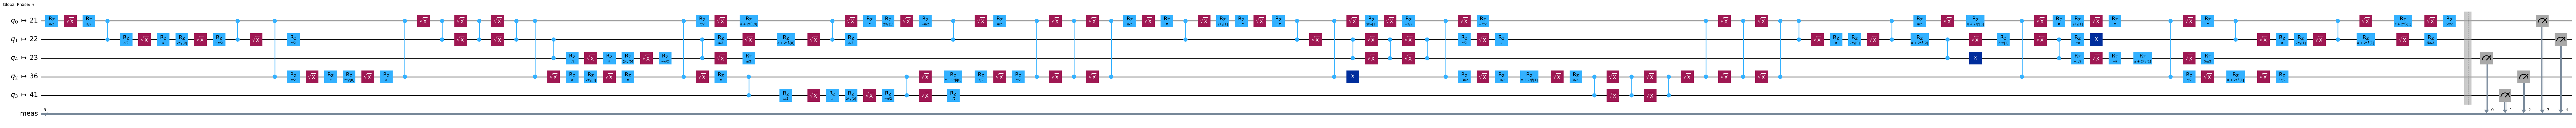

In [7]:
import os
os.environ.pop("QISKIT_IBM_TOKEN", None)
os.environ.pop("QISKIT_IBM_INSTANCE", None)
os.environ.pop("QISKIT_IBM_CHANNEL", None)

service = QiskitRuntimeService(
    #channel="ibm_quantum_platform",
    #token="VCOTZ6Gp-lC87iRtXuO7UEYHw4ZOz2tKlxV7jMZpokmv",
    #instance="crn:v1:bluemix:public:quantum-computing:us-east:a/407ca19e17a241c49d094e4d01c47f57:61b62a1b-fdd6-4425-92d0-502f8dd00f40::"
)
backend = service.least_busy(
    operational=True, simulator=False, min_num_qubits=127
)
print(backend)

# Create pass manager for transpilation. Level 3 is the most aggressive
# preset: slower to transpile, but produces shorter circuits that are
# more robust to hardware noise.
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)

candidate_circuit = pm.run(circuit)
candidate_circuit.draw("mpl", fold=False, idle_wires=False)


# Looks like I can't run this on an open plan. Thanks a lot IBM

In [ ]:
estimator = qiskit.primatives.Estimator()

# More Tutorial

In [9]:
initial_gamma = np.pi
initial_beta = np.pi / 2
init_params = [initial_beta, initial_beta, initial_gamma, initial_gamma]

In [10]:
def cost_func_estimator(params, ansatz, hamiltonian, estimator):
    # transform the observable defined on virtual qubits to
    # an observable defined on all physical qubits
    isa_hamiltonian = hamiltonian.apply_layout(ansatz.layout)

    pub = (ansatz, isa_hamiltonian, params)
    job = estimator.run([pub])

    results = job.result()[0]
    cost = results.data.evs

    objective_func_vals.append(cost)

    return cost

In [11]:
objective_func_vals = []  # Global variable
with Session(backend=backend) as session:
    # If using qiskit-ibm-runtime<0.24.0, change `mode=` to `session=`
    estimator = Estimator(mode=session)
    estimator.options.default_shots = 50

    # Set simple error suppression/mitigation options
    estimator.options.dynamical_decoupling.enable = True
    estimator.options.dynamical_decoupling.sequence_type = "XY4"
    estimator.options.twirling.enable_gates = True
    estimator.options.twirling.num_randomizations = "auto"
    estimator.options.environment.job_tags = ["TUT_QAOA"]

    result = minimize(
        cost_func_estimator,
        init_params,
        args=(candidate_circuit, cost_hamiltonian, estimator),
        method="COBYLA",
        tol=1e-2,
    )
    print(result)

RequestsApiError: '400 Client Error: Bad Request for url: https://quantum.cloud.ibm.com/api/v1/sessions. {"errors":[{"code":1352,"message":"You are not authorized to run a session when using the open plan.","solution":"Create an instance of a different plan type or use a different [execution mode](https://quantum.cloud.ibm.com/docs/guides/execution-modes).","more_info":"https://cloud.ibm.com/apidocs/quantum-computing#error-handling"}],"trace":"d5211616-57fb-4b47-80a7-dffeecb4b677"}\n'

# This isn't finished

I'm really not sure what all this code does yet
In turn, I'm not sure how to run the QAOAAntsatz on qiskit_aer yet.
I'll keep working on it later